In [272]:
# Importing dependencies
%load_ext autoreload
%autoreload 2

import itertools
import yaml
import os
import pickle
import pandas as pd
import matplotlib
matplotlib.rcParams['text.usetex'] = False
import matplotlib.pyplot as plt
import scienceplots

import logging

# logging.getLogger('matplotlib').setLevel(logging.WARNING)

# plt.style.use('science')

# # exact textwidth I got from latex
# textwidth = 6.00117/2
# aspect_ratio = 6/8
# scale = 1.0
# width = textwidth * scale
# height = width * aspect_ratio
# plt.figure(figsize=(width, height))


# # # Adjust tick parameters
# plt.tick_params(axis='both', which='major', labelsize=12)
# plt.tick_params(axis='both', which='minor', labelsize=10)

# plt.rcParams['axes.linewidth'] = 1.5
from clustercausal.experiments.ExperimentRunner import ExperimentRunner
from clustercausal.utils.Utils import *
from clustercausal.experiments.Utils import load_experiment_folder

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Plots

In [273]:
simul1data = pd.read_pickle('clustercausal\experiments\_results_dataframes_for_simulations\cluster_pc_simulation_1new_kpc.pkl')
# simul1data 'FCITiers' metrics are really k-PC for k=2, rename with a regex accordingly
simul1data.rename(columns=lambda x: x.replace('fcitiers', 'kPC') if 'fcitiers' in x else x, inplace=True)
simul1data.rename(columns={'C-PC indep tests': 'Cluster indep tests'}, inplace=True)
simul2data = pd.read_pickle('clustercausal\experiments\_results_dataframes_for_simulations\cluster_pc_simulation_2new.pkl')
simul2data.rename(columns={'C-PC indep tests': 'Cluster indep tests'}, inplace=True)
simul3data = pd.read_pickle('clustercausal\experiments\_results_dataframes_for_simulations\cluster_vsfcitiers_simulation_3new.pkl')
simul4data = pd.read_pickle('clustercausal\experiments\_results_dataframes_for_simulations\cluster_vsfcitiers_on_tiers_simulation_4new.pkl')

In [274]:
print(simul1data.shape)
print(simul2data.shape)
print(simul3data.shape)
print(simul4data.shape)

(12600, 112)
(3240, 88)
(1620, 112)
(1620, 112)


In [275]:
# data_all = pd.concat([data, data_ablation_alpha], ignore_index=True)
data_all = simul1data
data = simul2data
data_all.describe()

,base_adj_f1_score,base_adj_false_negative,base_adj_false_positive,base_adj_precision,base_adj_recall,base_adj_true_negative,base_adj_true_positive,base_arrow_f1_score,base_arrow_f1_score_ce,base_arrow_false_negative,...,alpha,cluster_connectivity,empty_graph_shd,n_clusters,n_edges,n_nodes,noise_scale,sample_size,true_sid_lower,true_sid_upper
count,12600.000000,12600.000000,12600.000000,12600.000000,12600.000000,12600.000000,12600.000000,12580.000000,12578.000000,12600.000000,...,12600.000000,10800.000000,12600.000000,12600.000000,12600.000000,12600.000000,12600.0,12600.000000,0.0,0.0
mean,0.654665,20.207302,7.372460,0.798081,0.636157,194.446746,21.306825,0.385447,0.583622,30.023413,...,0.182000,0.796859,41.514127,4.000000,43.750000,21.666667,1.0,1433.333333,NaN,NaN
std,0.191795,20.497748,12.187489,0.186673,0.254484,137.281951,8.634070,0.181627,0.159305,22.281957,...,0.178602,0.229500,23.735686,2.000079,24.335869,6.236343,0.0,1144.112222,NaN,NaN
min,0.070922,0.000000,0.000000,0.036765,0.088235,11.000000,2.000000,0.000000,0.000000,0.000000,...,0.010000,0.047619,3.000000,1.000000,15.000000,15.000000,1.0,300.000000,NaN,NaN
25%,0.506253,3.000000,2.000000,0.738872,0.413793,80.000000,15.000000,0.241758,0.481481,11.000000,...,0.050000,0.666667,21.000000,2.000000,26.250000,15.000000,1.0,300.000000,NaN,NaN
50%,0.676056,12.000000,4.000000,0.846154,0.666667,147.000000,20.000000,0.372549,0.595745,23.000000,...,0.100000,0.866667,37.000000,4.000000,40.000000,20.000000,1.0,1000.000000,NaN,NaN
75%,0.810811,34.000000,8.000000,0.925000,0.866667,358.000000,26.000000,0.514286,0.697674,46.000000,...,0.250000,1.000000,61.000000,6.000000,57.500000,30.000000,1.0,3000.000000,NaN,NaN
max,1.000000,86.000000,131.000000,1.000000,1.000000,430.000000,52.000000,1.000000,1.000000,93.000000,...,0.500000,1.000000,102.000000,7.000000,80.000000,30.000000,1.0,3000.000000,NaN,NaN


In [276]:
data_all['alpha'].unique()

array([0.01, 0.05, 0.1 , 0.25, 0.5 ])

In [277]:
# data_all = data.copy()
prec_recall_metrics = ['base_adj_precision', 'cluster_adj_precision', \
              'base_adj_recall', 'cluster_adj_recall', \
                'base_adj_f1_score', 'cluster_adj_f1_score']

In [278]:
indep_test_metrics = ['Base indep tests', 'Cluster indep tests']
dist_metrics = ['base_base_shd', 'cluster_cluster_shd', 'empty_graph_shd']

In [279]:
grouped_data = data_all.groupby('alpha')[prec_recall_metrics].mean()
grouped_data[prec_recall_metrics]

,base_adj_precision,cluster_adj_precision,base_adj_recall,cluster_adj_recall,base_adj_f1_score,cluster_adj_f1_score
alpha,,,,,,
0.01,0.920041,0.899232,0.596066,0.655249,0.696057,0.739266
0.05,0.878075,0.839038,0.619700,0.679334,0.693599,0.725424
0.10,0.833583,0.784821,0.632797,0.691354,0.678919,0.701592
0.25,0.734175,0.669980,0.653357,0.714385,0.631777,0.640069
0.50,0.624533,0.550950,0.678866,0.741243,0.572975,0.565355


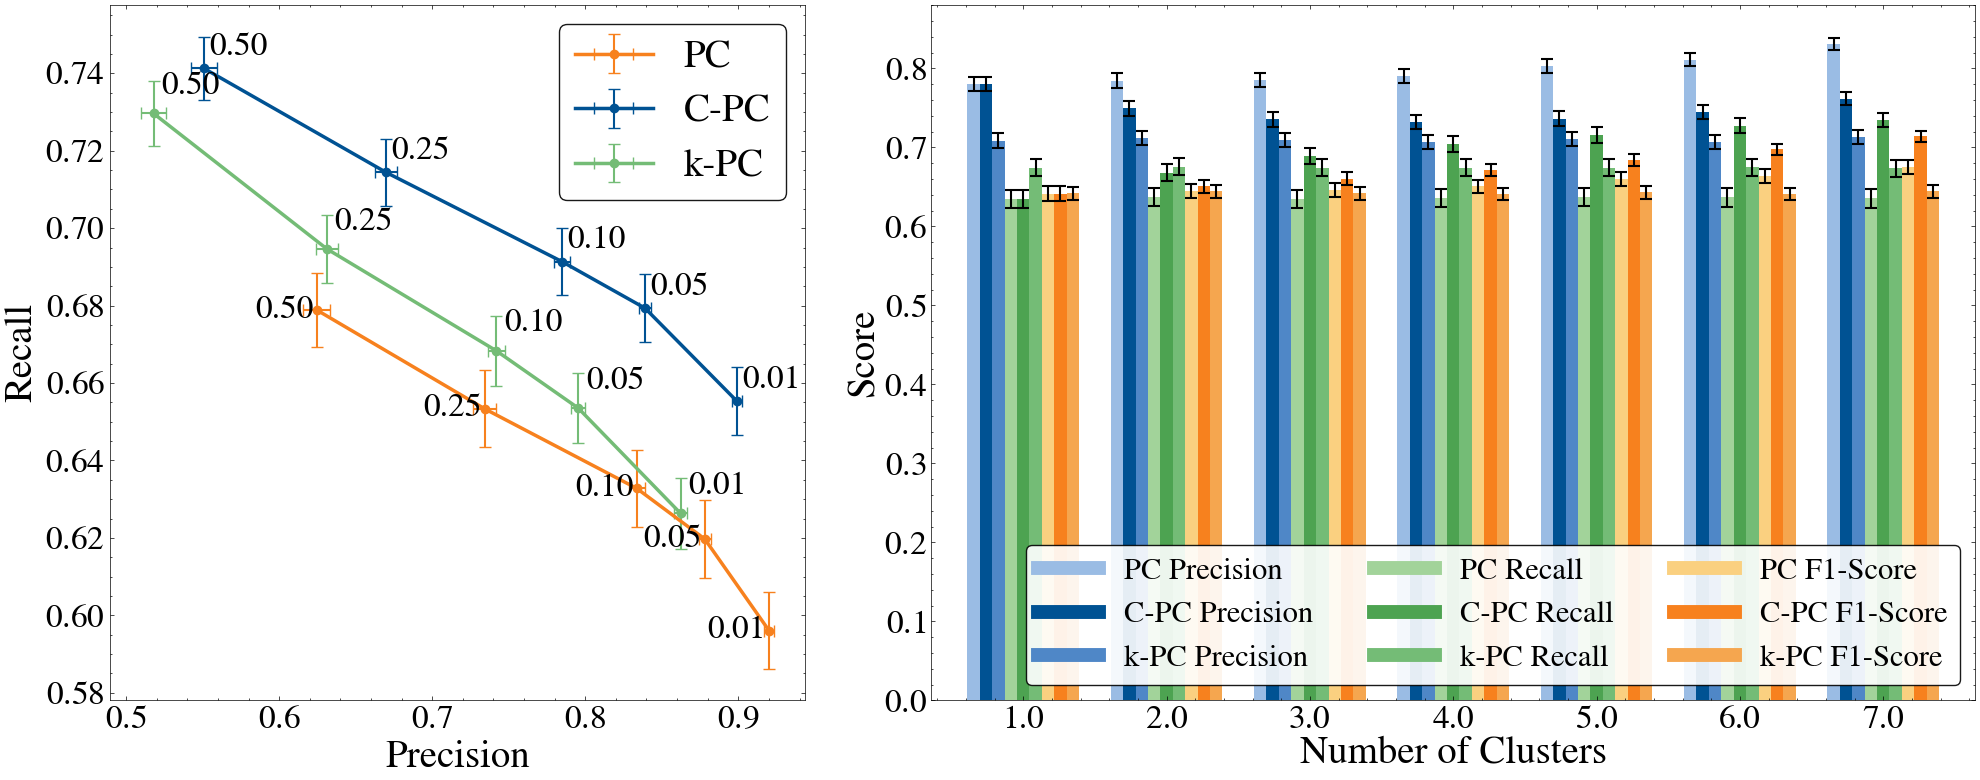

In [280]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from scipy import stats
plt.style.use(['science', 'no-latex'])

ci_level = 0.95

def t_ci_halfwidth(se_df, n_df, confidence=0.95):
    t_crit = n_df.apply(
        lambda col: col.map(
            lambda n: stats.t.ppf((1 + confidence) / 2, n - 1) if n > 1 else float('nan')
        )
    )
    return (se_df * t_crit).fillna(0)

metric_order = ['adj_precision', 'adj_recall', 'adj_f1_score']
metric_label_map = {
    'adj_precision': 'Precision',
    'adj_recall': 'Recall',
    'adj_f1_score': 'F1-Score',
}

algo_specs = [
    ('base', 'PC', '#F7811E', '#9ABCE4'),
    ('cluster', 'C-PC', '#005293', '#005293'),
    ('kPC', 'k-PC', '#74BC76', '#4F87C7'),
]
available_algos = [
    (prefix, label, pr_color, default_bar_color)
    for prefix, label, pr_color, default_bar_color in algo_specs
    if all(f'{prefix}_{metric}' in data_all.columns for metric in metric_order)
]

if len(available_algos) < 2:
    raise ValueError('Need at least two algorithm outputs (e.g., base/cluster/kPC) with adj_precision/adj_recall/adj_f1_score columns.')

prec_recall_metrics_plot = [
    f'{prefix}_{metric}'
    for metric in metric_order
    for prefix, _, _, _ in available_algos
]

# Create the figure and specify gridspec for unequal subplot widths
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(1, 2, width_ratios=[2, 3])  # 40% for ax1 and 60% for ax2

# First Plot: Precision-Recall Curve for different alpha values (mean +/- 95% CI)
ax1 = fig.add_subplot(gs[0])
grouped_stats = data_all.groupby('alpha')[prec_recall_metrics_plot].agg(['mean', 'sem', 'count']).fillna(0)
grouped_mean = grouped_stats.xs('mean', axis=1, level=1)
grouped_se = grouped_stats.xs('sem', axis=1, level=1)
grouped_n = grouped_stats.xs('count', axis=1, level=1)
grouped_ci = t_ci_halfwidth(grouped_se, grouped_n, confidence=ci_level)

for i, (prefix, label, pr_color, _) in enumerate(available_algos):
    ax1.errorbar(
        grouped_mean[f'{prefix}_adj_precision'],
        grouped_mean[f'{prefix}_adj_recall'],
        xerr=grouped_ci[f'{prefix}_adj_precision'],
        yerr=grouped_ci[f'{prefix}_adj_recall'],
        fmt='-o',
        color=pr_color,
        label=label,
        linewidth=2.5,
        capsize=4,
        elinewidth=1.5
)
    offset = 0.002 + i * 0.0015
    sign = -1 if i == 0 else 1
    for alpha, x, y in zip(
        grouped_mean.index,
        grouped_mean[f'{prefix}_adj_precision'],
        grouped_mean[f'{prefix}_adj_recall'],
    ):
        ax1.text(
            x + sign * offset,
            y + sign * offset,
            f'{alpha:.2f}',
            fontsize=24,
            ha='left' if sign > 0 else 'right',
        )

# Set labels and style the legend for ax1
ax1.set_xlabel('Precision', fontsize=28)
ax1.set_ylabel('Recall', fontsize=28)
ax1.tick_params(axis='both', which='major', labelsize=24)

legend = ax1.legend(fontsize=28, loc='upper right', frameon=True, ncol=1)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_alpha(0.9)

# Second Plot: Bar plot for Precision, Recall, and F1-Score for Different Numbers of Clusters (mean +/- 95% CI)
ax2 = fig.add_subplot(gs[1])
pr_stats = data_all.groupby('n_clusters')[prec_recall_metrics_plot].agg(['mean', 'sem', 'count']).fillna(0)
pr_mean = pr_stats.xs('mean', axis=1, level=1)
pr_se = pr_stats.xs('sem', axis=1, level=1)
pr_n = pr_stats.xs('count', axis=1, level=1)
pr_ci = t_ci_halfwidth(pr_se, pr_n, confidence=ci_level)

bar_palette = {
    'PC': {'adj_precision': '#9ABCE4', 'adj_recall': '#A2D39A', 'adj_f1_score': '#FAD080'},
    'C-PC': {'adj_precision': '#005293', 'adj_recall': '#4DA351', 'adj_f1_score': '#F7811E'},
    'k-PC': {'adj_precision': '#4F87C7', 'adj_recall': '#74BC76', 'adj_f1_score': '#F5A64F'},
}
default_bar_colors = {label: default_color for _, label, _, default_color in available_algos}
bar_colors = [
    bar_palette.get(label, {}).get(metric, default_bar_colors[label])
    for metric in metric_order
    for _, label, _, _ in available_algos
]

pr_mean.plot(
    kind='bar',
    ax=ax2,
    color=bar_colors,
    width=0.78,
    yerr=pr_ci,
    capsize=4,
    error_kw={'elinewidth': 1.5, 'capthick': 1.5}
)

# Label enhancements for ax2
ax2.set_xlabel('Number of Clusters', fontsize=28, labelpad=1)
ax2.set_ylabel('Score', fontsize=28, labelpad=1)
ax2.tick_params(axis='both', which='major', labelsize=24)
ax2.tick_params(axis='x', which='major', labelsize=24, rotation=0)

label_names = [
    f'{label} {metric_label_map[metric]}'
    for metric in metric_order
    for _, label, _, _ in available_algos
]
colored_handles = [plt.Line2D([0], [0], color=color, lw=10) for color in bar_colors]
legend = ax2.legend(
    colored_handles,
    label_names,
    loc='lower right',
    fontsize=22,
    frameon=True,
    ncol=len(available_algos),
)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_alpha(0.9)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig('imgs/combined_prec_recall_clusters_diagram.pdf', bbox_inches='tight')
plt.show()

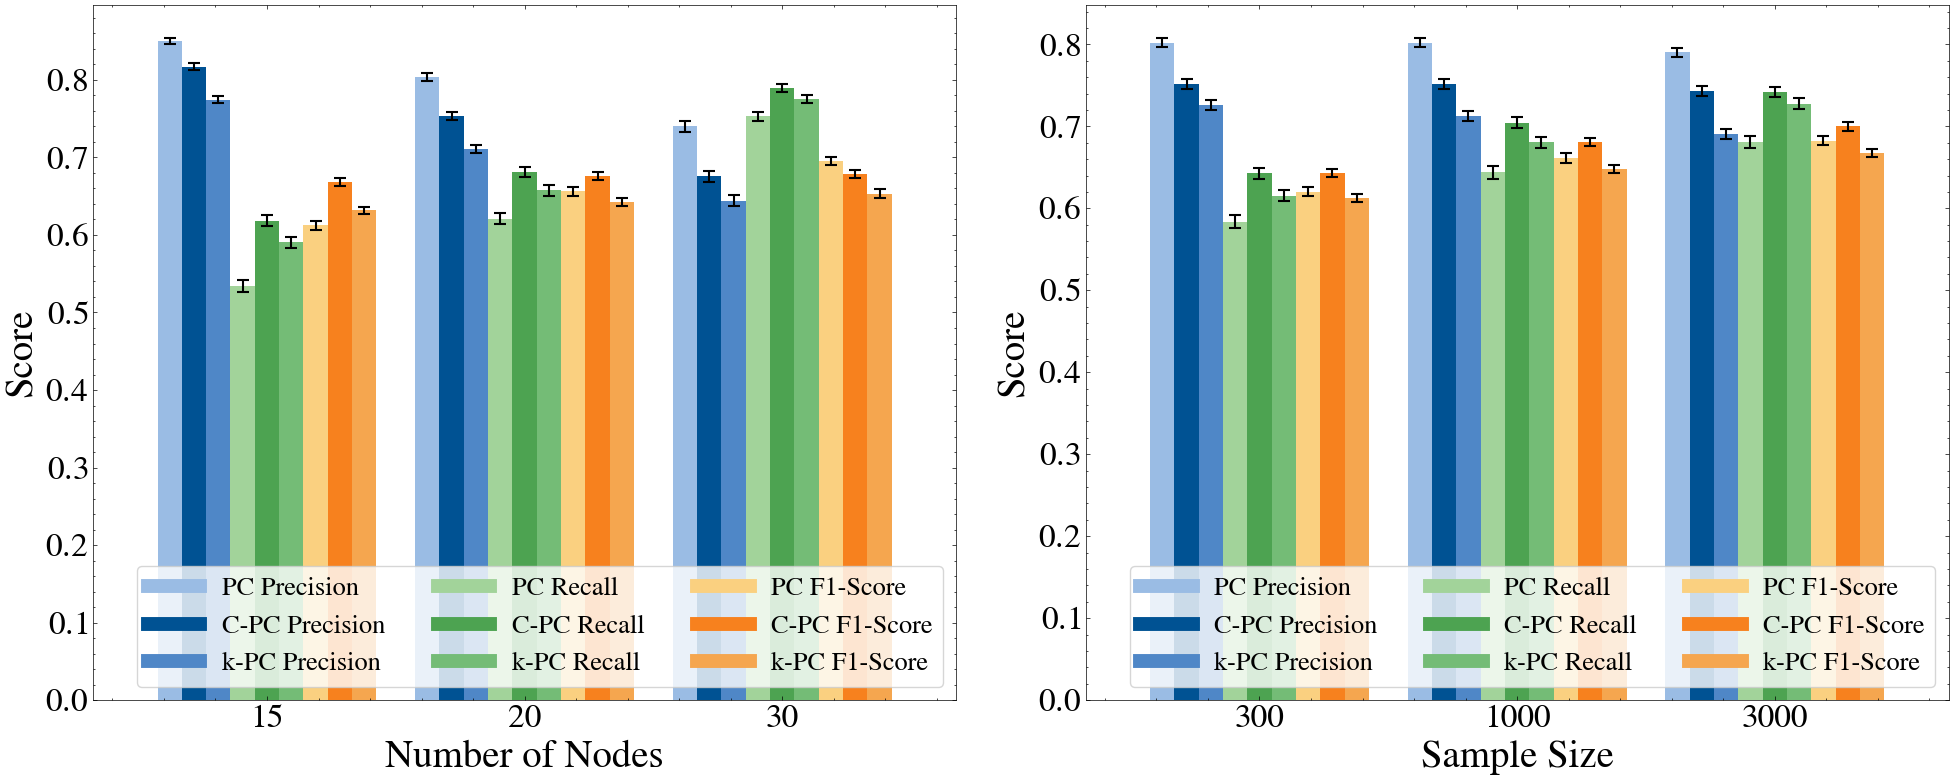

In [281]:
# Start here
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use(['science', 'no-latex'])

ci_level = 0.95

def t_ci_halfwidth(se_df, n_df, confidence=0.95):
    t_crit = n_df.apply(
        lambda col: col.map(
            lambda n: stats.t.ppf((1 + confidence) / 2, n - 1) if n > 1 else float('nan')
        )
    )
    return (se_df * t_crit).fillna(0)

metric_order = ['adj_precision', 'adj_recall', 'adj_f1_score']
metric_label_map = {
    'adj_precision': 'Precision',
    'adj_recall': 'Recall',
    'adj_f1_score': 'F1-Score',
}

algo_specs = [
    ('base', 'PC', '#9ABCE4'),
    ('cluster', 'C-PC', '#005293'),
    ('kPC', 'k-PC', '#4F87C7'),
]
available_algos = [
    (prefix, label, default_bar_color)
    for prefix, label, default_bar_color in algo_specs
    if all(f'{prefix}_{metric}' in data_all.columns for metric in metric_order)
]

if len(available_algos) < 2:
    raise ValueError('Need at least two algorithm outputs (e.g., base/cluster/kPC) with adj_precision/adj_recall/adj_f1_score columns.')

prec_recall_metrics_plot = [
    f'{prefix}_{metric}'
    for metric in metric_order
    for prefix, _, _ in available_algos
]

bar_palette = {
    'PC': {'adj_precision': '#9ABCE4', 'adj_recall': '#A2D39A', 'adj_f1_score': '#FAD080'},
    'C-PC': {'adj_precision': '#005293', 'adj_recall': '#4DA351', 'adj_f1_score': '#F7811E'},
    'k-PC': {'adj_precision': '#4F87C7', 'adj_recall': '#74BC76', 'adj_f1_score': '#F5A64F'},
}
default_bar_colors = {label: default_bar_color for _, label, default_bar_color in available_algos}
bar_colors = [
    bar_palette.get(label, {}).get(metric, default_bar_colors[label])
    for metric in metric_order
    for _, label, _ in available_algos
]
label_names = [
    f'{label} {metric_label_map[metric]}'
    for metric in metric_order
    for _, label, _ in available_algos
]
colored_handles = [plt.Line2D([0], [0], color=color, lw=10) for color in bar_colors]

# Left plot: grouped by number of nodes
nodes_stats = data_all.groupby('n_nodes')[prec_recall_metrics_plot].agg(['mean', 'sem', 'count']).fillna(0)
nodes_mean = nodes_stats.xs('mean', axis=1, level=1)
nodes_se = nodes_stats.xs('sem', axis=1, level=1)
nodes_n = nodes_stats.xs('count', axis=1, level=1)
nodes_ci = t_ci_halfwidth(nodes_se, nodes_n, confidence=ci_level)

# Right plot: grouped by sample size
sample_stats = data_all.groupby('sample_size')[prec_recall_metrics_plot].agg(['mean', 'sem', 'count']).fillna(0)
sample_mean = sample_stats.xs('mean', axis=1, level=1)
sample_se = sample_stats.xs('sem', axis=1, level=1)
sample_n = sample_stats.xs('count', axis=1, level=1)
sample_ci = t_ci_halfwidth(sample_se, sample_n, confidence=ci_level)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

nodes_mean.plot(
    kind='bar',
    ax=ax1,
    color=bar_colors,
    width=0.85,
    yerr=nodes_ci,
    capsize=4,
    error_kw={'elinewidth': 1.5, 'capthick': 1.5}
)
ax1.set_xlabel('Number of Nodes', fontsize=28)
ax1.set_ylabel('Score', fontsize=28)
ax1.tick_params(axis='both', which='major', labelsize=24)
ax1.tick_params(axis='x', which='major', labelsize=24, rotation=0)
ax1.set_xticklabels([f"{int(float(label.get_text()))}" for label in ax1.get_xticklabels()])
ax1.legend(
    colored_handles,
    label_names,
    loc='lower right',
    fontsize=19,
    frameon=True,
    ncol=len(available_algos),
)

sample_mean.plot(
    kind='bar',
    ax=ax2,
    color=bar_colors,
    width=0.85,
    yerr=sample_ci,
    capsize=4,
    error_kw={'elinewidth': 1.5, 'capthick': 1.5}
)
ax2.set_xlabel('Sample Size', fontsize=28)
ax2.set_ylabel('Score', fontsize=28)
ax2.tick_params(axis='both', which='major', labelsize=24)
ax2.tick_params(axis='x', which='major', labelsize=24, rotation=0)
ax2.set_xticklabels([f"{int(float(label.get_text()))}" for label in ax2.get_xticklabels()])
ax2.legend(
    colored_handles,
    label_names,
    loc='lower right',
    fontsize=19,
    frameon=True,
    ncol=len(available_algos),
)

plt.tight_layout()
plt.savefig('imgs/combined_prec_recall_grouped_nodes_and_sample_size.pdf', bbox_inches='tight')
plt.show()

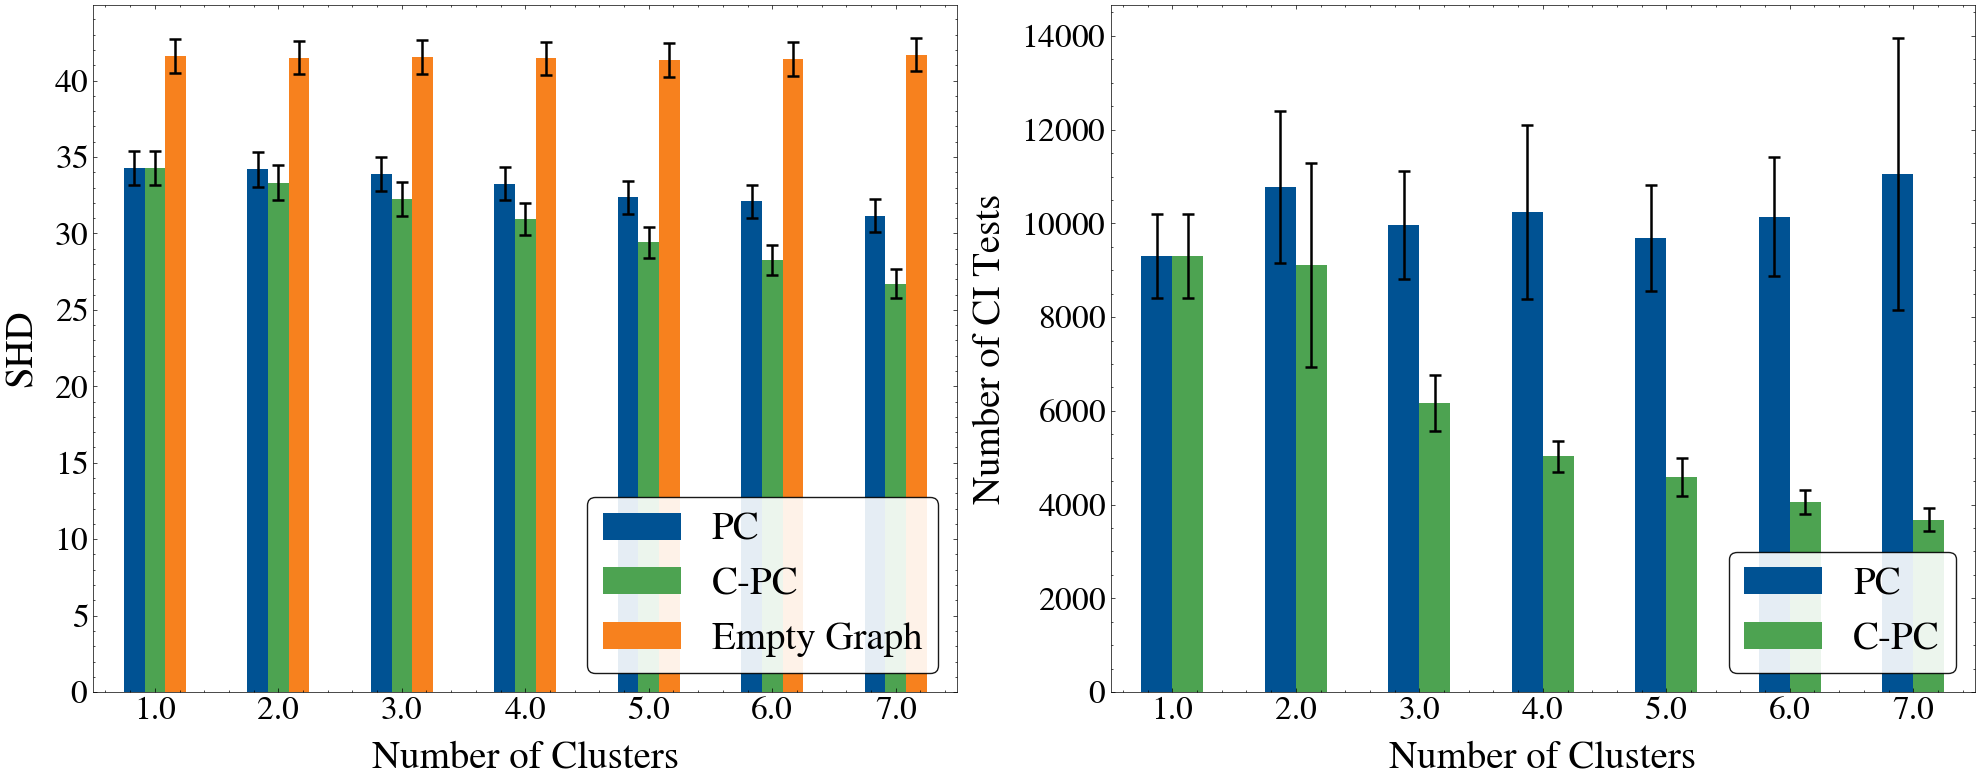

In [282]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots
from scipy import stats

# Use the 'science' style from scienceplots
plt.style.use(['science', 'no-latex'])  # 'no-latex' avoids LaTeX processing for quicker rendering

# Define colors for each plot
colors_shd = ['#005293', '#4DA351', '#F7811E']
colors_ci_tests = colors_shd

ci_level = 0.95

def t_ci_halfwidth(se_df, n_df, confidence=0.95):
    t_crit = n_df.apply(
        lambda col: col.map(
            lambda n: stats.t.ppf((1 + confidence) / 2, n - 1) if n > 1 else float('nan')
        )
    )
    return (se_df * t_crit).fillna(0)

# Aggregate mean and 95% t-based CI half-width
shd_stats = data_all.groupby('n_clusters')[dist_metrics].agg(['mean', 'sem', 'count']).fillna(0)
shd_mean = shd_stats.xs('mean', axis=1, level=1)
shd_se = shd_stats.xs('sem', axis=1, level=1)
shd_n = shd_stats.xs('count', axis=1, level=1)
shd_ci = t_ci_halfwidth(shd_se, shd_n, confidence=ci_level)

tests_stats = data_all.groupby('n_clusters')[indep_test_metrics].agg(['mean', 'sem', 'count']).fillna(0)
tests_mean = tests_stats.xs('mean', axis=1, level=1)
tests_se = tests_stats.xs('sem', axis=1, level=1)
tests_n = tests_stats.xs('count', axis=1, level=1)
tests_ci = t_ci_halfwidth(tests_se, tests_n, confidence=ci_level)

# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))  # Side-by-side subplots

# First plot - SHD for different numbers of clusters (mean +/- 95% CI)
shd_mean.plot(
    kind='bar',
    ax=ax1,
    color=colors_shd,
    yerr=shd_ci,
    capsize=4,
    error_kw={'elinewidth': 1.8, 'capthick': 1.8}
 )
ax1.set_xlabel('Number of Clusters', fontsize=28, labelpad=10)
ax1.set_ylabel('SHD', fontsize=28, labelpad=10)
ax1.tick_params(axis='both', which='major', labelsize=24)
ax1.tick_params(axis='x', which='major', labelsize=24, rotation=0)
label_names_shd = ['PC', 'C-PC', 'Empty Graph']
legend1 = ax1.legend(label_names_shd, loc='lower right', fontsize=28, frameon=True)
legend1.get_frame().set_facecolor('white')
legend1.get_frame().set_edgecolor('black')
legend1.get_frame().set_alpha(0.9)

# Second plot - Number of CI tests needed for different numbers of clusters (mean +/- 95% CI)
tests_mean.plot(
    kind='bar',
    ax=ax2,
    color=colors_ci_tests,
    yerr=tests_ci,
    capsize=4,
    error_kw={'elinewidth': 1.8, 'capthick': 1.8}
 )
ax2.set_xlabel('Number of Clusters', fontsize=28, labelpad=10)
ax2.set_ylabel('Number of CI Tests', fontsize=28, labelpad=10)
ax2.tick_params(axis='both', which='major', labelsize=24)
ax2.tick_params(axis='x', which='major', labelsize=24, rotation=0)
label_names_ci = ['PC', 'C-PC']
legend2 = ax2.legend(label_names_ci, loc='lower right', fontsize=28, frameon=True)
legend2.get_frame().set_facecolor('white')
legend2.get_frame().set_edgecolor('black')
legend2.get_frame().set_alpha(0.9)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig('imgs/combined_shd_ci_tests_clusters_diagram.pdf', bbox_inches='tight')
plt.show()

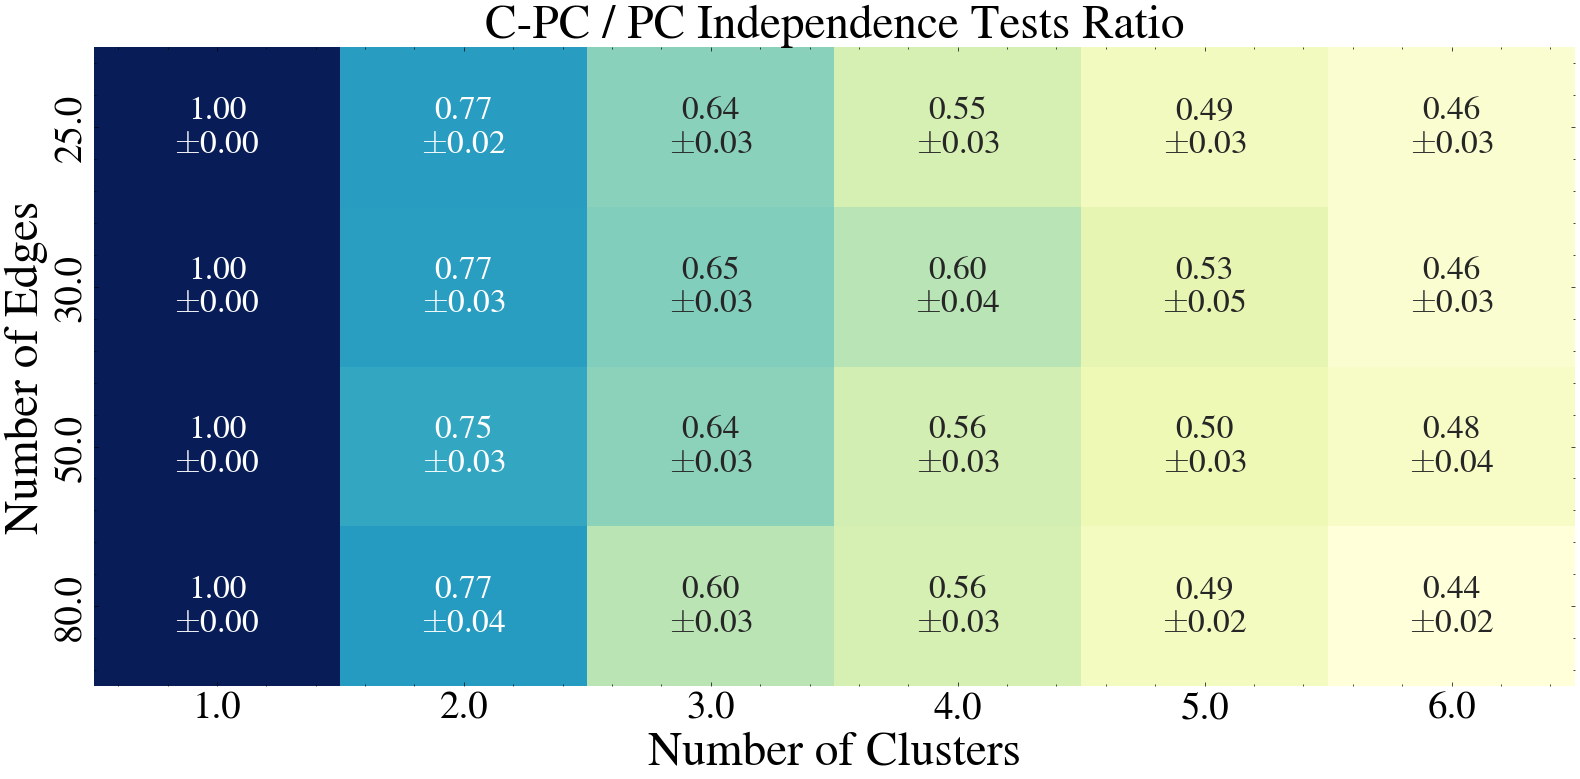

In [283]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

ci_level = 0.95

def t_ci_halfwidth(se_df, n_df, confidence=0.95):
    t_crit = n_df.apply(
        lambda col: col.map(
            lambda n: stats.t.ppf((1 + confidence) / 2, n - 1) if n > 1 else float('nan')
        )
    )
    return (se_df * t_crit).fillna(0)

# Compute per-run ratio first, then aggregate mean/SE/count for the ratio
ratio_data = data.copy()
ratio_data['ratio_cluster_over_base'] = (
    ratio_data['Cluster indep tests'] / ratio_data['Base indep tests'].replace(0, np.nan)
)
ratio_data = ratio_data.replace([np.inf, -np.inf], np.nan)

ratio_stats = ratio_data.groupby(['n_edges', 'n_clusters'])['ratio_cluster_over_base'].agg(['mean', 'sem', 'count'])
ratio_mean = ratio_stats['mean'].unstack('n_clusters').fillna(0)
ratio_se = ratio_stats['sem'].unstack('n_clusters')
ratio_n = ratio_stats['count'].unstack('n_clusters')
ratio_ci = t_ci_halfwidth(ratio_se, ratio_n, confidence=ci_level).fillna(0)

# Create annotation strings as mean +/- 95% CI
ratio_annot = ratio_mean.copy().astype(object)
for row in ratio_mean.index:
    for col in ratio_mean.columns:
        ratio_annot.loc[row, col] = f"{ratio_mean.loc[row, col]:.2f}\n$\\pm${ratio_ci.loc[row, col]:.2f}"

plt.figure(figsize=(16, 8))
labelsize = 28
fontsize = 34
annot_fontsize = 24
sns.heatmap(
    ratio_mean,
    annot=ratio_annot,
    fmt='',
    cmap='YlGnBu',
    cbar=False,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': annot_fontsize}
 )
plt.title('C-PC / PC Independence Tests Ratio', fontsize=fontsize)
plt.xlabel('Number of Clusters', fontsize=fontsize)
plt.ylabel('Number of Edges', fontsize=fontsize)
plt.tick_params(axis='x', labelsize=labelsize)
plt.tick_params(axis='y', labelsize=labelsize)

# Adjust layout
plt.tight_layout()
plt.savefig('imgs/indep_tests_ratio_over_n_edges_heatmap.pdf', bbox_inches='tight')
plt.show()


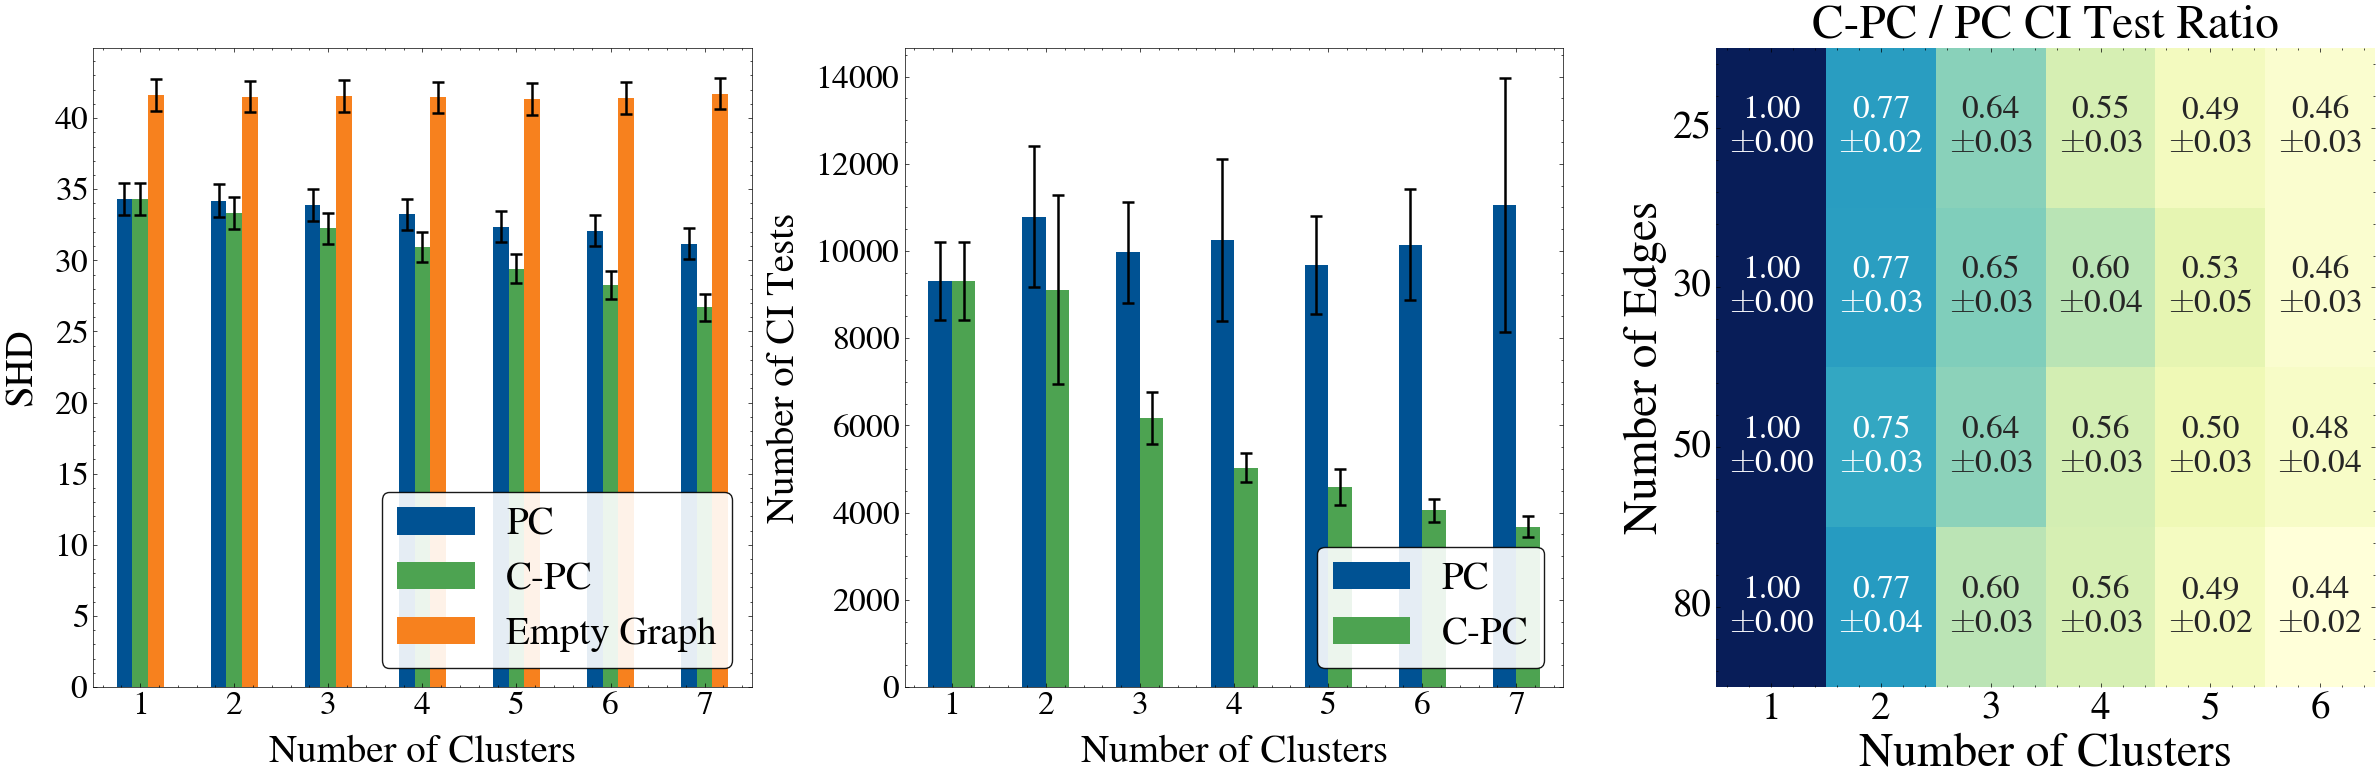

In [284]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
from scipy import stats
# import scienceplots # Removed due to unavailability

# Define colors for each plot
colors_shd = ['#005293', '#4DA351', '#F7811E']
colors_ci_tests = colors_shd

ci_level = 0.95

def t_ci_halfwidth(se_df, n_df, confidence=0.95):
    t_crit = n_df.apply(
        lambda col: col.map(
            lambda n: stats.t.ppf((1 + confidence) / 2, n - 1) if n > 1 else float('nan')
        )
    )
    return (se_df * t_crit).fillna(0)

# Aggregate mean/SE/count for bar plots
shd_stats = data_all.groupby('n_clusters')[dist_metrics].agg(['mean', 'sem', 'count']).fillna(0)
shd_mean = shd_stats.xs('mean', axis=1, level=1)
shd_se = shd_stats.xs('sem', axis=1, level=1)
shd_n = shd_stats.xs('count', axis=1, level=1)
shd_ci = t_ci_halfwidth(shd_se, shd_n, confidence=ci_level)

tests_stats = data_all.groupby('n_clusters')[indep_test_metrics].agg(['mean', 'sem', 'count']).fillna(0)
tests_mean = tests_stats.xs('mean', axis=1, level=1)
tests_se = tests_stats.xs('sem', axis=1, level=1)
tests_n = tests_stats.xs('count', axis=1, level=1)
tests_ci = t_ci_halfwidth(tests_se, tests_n, confidence=ci_level)

# Heatmap data: compute ratio per run first, then CI from ratio SE
ratio_data = data.copy()
ratio_data['ratio_cluster_over_base'] = (
    ratio_data['Cluster indep tests'] / ratio_data['Base indep tests'].replace(0, np.nan)
)
ratio_data = ratio_data.replace([np.inf, -np.inf], np.nan)

ratio_stats = ratio_data.groupby(['n_edges', 'n_clusters'])['ratio_cluster_over_base'].agg(['mean', 'sem', 'count'])
ratio_mean = ratio_stats['mean'].unstack('n_clusters').fillna(0)
ratio_se = ratio_stats['sem'].unstack('n_clusters')
ratio_n = ratio_stats['count'].unstack('n_clusters')
ratio_ci = t_ci_halfwidth(ratio_se, ratio_n, confidence=ci_level).fillna(0)

ratio_annot = ratio_mean.copy().astype(object)
for row in ratio_mean.index:
    for col in ratio_mean.columns:
        ratio_annot.loc[row, col] = f"{ratio_mean.loc[row, col]:.2f}\n$\\pm${ratio_ci.loc[row, col]:.2f}"

# Create the figure and subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))  # Side-by-side subplots

# First plot - SHD for different numbers of clusters (mean +/- 95% CI)
shd_mean.plot(
    kind='bar',
    ax=ax1,
    color=colors_shd,
    yerr=shd_ci,
    capsize=4,
    error_kw={'elinewidth': 1.8, 'capthick': 1.8}
 )
ax1.set_xlabel('Number of Clusters', fontsize=28, labelpad=10)
ax1.set_ylabel('SHD', fontsize=28, labelpad=10)
ax1.tick_params(axis='both', which='major', labelsize=24)
ax1.tick_params(axis='x', which='major', labelsize=24, rotation=0)
ax1.set_xticklabels([f"{int(float(label.get_text()))}" for label in ax1.get_xticklabels()])
label_names_shd = ['PC', 'C-PC', 'Empty Graph']
legend1 = ax1.legend(label_names_shd, loc='lower right', fontsize=28, frameon=True)
legend1.get_frame().set_facecolor('white')
legend1.get_frame().set_edgecolor('black')
legend1.get_frame().set_alpha(0.9)

# Second plot - Number of CI tests needed for different numbers of clusters (mean +/- 95% CI)
tests_mean.plot(
    kind='bar',
    ax=ax2,
    color=colors_ci_tests,
    yerr=tests_ci,
    capsize=4,
    error_kw={'elinewidth': 1.8, 'capthick': 1.8}
 )
ax2.set_xlabel('Number of Clusters', fontsize=28, labelpad=10)
ax2.set_ylabel('Number of CI Tests', fontsize=28, labelpad=10)
ax2.tick_params(axis='both', which='major', labelsize=24)
ax2.tick_params(axis='x', which='major', labelsize=24, rotation=0)
ax2.set_xticklabels([f"{int(float(label.get_text()))}" for label in ax2.get_xticklabels()])
label_names_ci = ['PC', 'C-PC']
legend2 = ax2.legend(label_names_ci, loc='lower right', fontsize=28, frameon=True)
legend2.get_frame().set_facecolor('white')
legend2.get_frame().set_edgecolor('black')
legend2.get_frame().set_alpha(0.9)

# Third Plot - Ratio heatmap with mean +/- 95% CI annotations
labelsize = 28
fontsize = 34
annot_fontsize = 24
sns.heatmap(
    ratio_mean,
    annot=ratio_annot,
    fmt='',
    cmap='YlGnBu',
    cbar=False,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': annot_fontsize},
    ax=ax3
)
ax3.set_title('C-PC / PC CI Test Ratio', fontsize=fontsize)
ax3.set_xlabel('Number of Clusters', fontsize=fontsize)
ax3.set_ylabel('Number of Edges', fontsize=fontsize)
ax3.tick_params(axis='x', labelsize=labelsize)
ax3.tick_params(axis='y', labelsize=labelsize)
ax3.set_xticklabels([f"{int(float(label.get_text()))}" for label in ax3.get_xticklabels()], rotation=0)
ax3.set_yticklabels([f"{int(float(label.get_text()))}" for label in ax3.get_yticklabels()], rotation=0)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig('imgs/combined_shd_ci_tests_clusters_diagram_and_ci_test_ratios_over_edges.pdf', bbox_inches='tight')
plt.show()

# Tables

In [285]:
from clustercausal.utils.Utils import metrics_in_readable_table
import pandas as pd
from scipy import stats

simul1data = pd.read_pickle('clustercausal\\experiments\\_results_dataframes_for_simulations\\cluster_pc_simulation_1new_kpc.pkl')
# simul1data 'FCITiers' metrics are really k-PC for k=2, rename with a regex accordingly
simul1data.rename(columns=lambda x: x.replace('fcitiers', 'kPC') if 'fcitiers' in x else x, inplace=True)
# simul1data.rename(columns={'C-PC indep tests': 'Cluster indep tests'}, inplace=True)
simul2data = pd.read_pickle('clustercausal\\experiments\\_results_dataframes_for_simulations\\cluster_pc_simulation_2new.pkl')
# simul2data.rename(columns={'C-PC indep tests': 'Cluster indep tests'}, inplace=True)
simul3data = pd.read_pickle('clustercausal\\experiments\\_results_dataframes_for_simulations\\cluster_vsfcitiers_simulation_3new.pkl')
simul4data = pd.read_pickle('clustercausal\\experiments\\_results_dataframes_for_simulations\\cluster_vsfcitiers_on_tiers_simulation_4new.pkl')

CI_CONFIDENCE = 0.95

def _col_mean_ci(df, candidates, confidence=0.95):
    for col in candidates:
        if col in df.columns:
            values = pd.to_numeric(df[col], errors='coerce').dropna()
            if values.empty:
                continue

            mean = values.mean()
            n = values.shape[0]

            if n > 1:
                se = values.sem(ddof=1)
                t_crit = stats.t.ppf((1 + confidence) / 2, n - 1)
                ci_halfwidth = t_crit * se if pd.notna(se) else float('nan')
            else:
                ci_halfwidth = float('nan')

            return mean, ci_halfwidth

    return float('nan'), float('nan')

def _fmt_pct_ci(mean, ci_halfwidth):
    if pd.isna(mean):
        return 'N/A'
    if pd.notna(ci_halfwidth):
        return f"{100 * mean:.1f}% ± {100 * ci_halfwidth:.1f}%"
    return f"{100 * mean:.1f}%"

def _fmt_float_ci(mean, ci_halfwidth):
    if pd.isna(mean):
        return 'N/A'
    if pd.notna(ci_halfwidth):
        return f"{mean:.1f} ± {ci_halfwidth:.1f}"
    return f"{mean:.1f}"

def _fmt_count_ci(mean, ci_halfwidth):
    if pd.isna(mean):
        return 'N/A'
    if pd.notna(ci_halfwidth):
        return f"{int(round(mean))} ± {ci_halfwidth:.1f}"
    return f"{int(round(mean))}"

def build_pretty_pc_cluster_table(df):
    metric_specs = [
        ('Adj. precision', ['base_adj_precision'], ['cluster_adj_precision'], ['kPC_adj_precision', 'fcitiers_adj_precision'], 'pct'),
        ('Arrow precision', ['base_arrow_precision'], ['cluster_arrow_precision'], ['kPC_arrow_precision', 'fcitiers_arrow_precision'], 'pct'),
        ('Adj. recall', ['base_adj_recall'], ['cluster_adj_recall'], ['kPC_adj_recall', 'fcitiers_adj_recall'], 'pct'),
        ('Arrow recall', ['base_arrow_recall'], ['cluster_arrow_recall'], ['kPC_arrow_recall', 'fcitiers_arrow_recall'], 'pct'),
        ('Adj. F1-score', ['base_adj_f1_score'], ['cluster_adj_f1_score'], ['kPC_adj_f1_score', 'fcitiers_adj_f1_score'], 'pct'),
        ('Arrow F1-score', ['base_arrow_f1_score'], ['cluster_arrow_f1_score'], ['kPC_arrow_f1_score', 'fcitiers_arrow_f1_score'], 'pct'),
        ('SHD', ['base_shd', 'base_base_shd'], ['cluster_shd', 'cluster_cluster_shd'], ['kPC_shd', 'kPC_kPC_shd', 'fcitiers_shd', 'fcitiers_fcitiers_shd'], 'float'),
        ('Avg. CI tests', ['base_indep_tests', 'Base indep tests'], ['cluster_indep_tests', 'Cluster indep tests', 'C-PC indep tests'], ['kPC_indep_tests', 'fcitiers_indep_tests', 'FCITiers indep tests'], 'int'),
    ]

    include_kpc = any(
        any(col in df.columns for col in kpc_cols)
        for _, _, _, kpc_cols, _ in metric_specs
    )

    rows = []
    for metric_name, base_cols, cluster_cols, kpc_cols, fmt in metric_specs:
        base_mean, base_ci = _col_mean_ci(df, base_cols, confidence=CI_CONFIDENCE)
        cluster_mean, cluster_ci = _col_mean_ci(df, cluster_cols, confidence=CI_CONFIDENCE)
        kpc_mean, kpc_ci = _col_mean_ci(df, kpc_cols, confidence=CI_CONFIDENCE)

        if fmt == 'pct':
            base_show = _fmt_pct_ci(base_mean, base_ci)
            cluster_show = _fmt_pct_ci(cluster_mean, cluster_ci)
            kpc_show = _fmt_pct_ci(kpc_mean, kpc_ci)
        elif fmt == 'int':
            base_show = _fmt_count_ci(base_mean, base_ci)
            cluster_show = _fmt_count_ci(cluster_mean, cluster_ci)
            kpc_show = _fmt_count_ci(kpc_mean, kpc_ci)
        else:
            base_show = _fmt_float_ci(base_mean, base_ci)
            cluster_show = _fmt_float_ci(cluster_mean, cluster_ci)
            kpc_show = _fmt_float_ci(kpc_mean, kpc_ci)

        if include_kpc:
            rows.append([metric_name, base_show, cluster_show, kpc_show])
        else:
            rows.append([metric_name, base_show, cluster_show])

    if include_kpc:
        return pd.DataFrame(rows, columns=['Metric', 'PC', 'Cluster-PC', 'k-PC'])
    return pd.DataFrame(rows, columns=['Metric', 'PC', 'Cluster-PC'])

def build_pretty_fci_cluster_fcitiers_table(df):
    metric_specs = [
        ('Adj. precision', ['base_adj_precision'], ['cluster_adj_precision'], ['fcitiers_adj_precision'], 'pct'),
        ('Arrow precision', ['base_arrow_precision'], ['cluster_arrow_precision'], ['fcitiers_arrow_precision'], 'pct'),
        ('Adj. recall', ['base_adj_recall'], ['cluster_adj_recall'], ['fcitiers_adj_recall'], 'pct'),
        ('Arrow recall', ['base_arrow_recall'], ['cluster_arrow_recall'], ['fcitiers_arrow_recall'], 'pct'),
        ('Adj. F1-score', ['base_adj_f1_score'], ['cluster_adj_f1_score'], ['fcitiers_adj_f1_score'], 'pct'),
        ('Arrow F1-score', ['base_arrow_f1_score'], ['cluster_arrow_f1_score'], ['fcitiers_arrow_f1_score'], 'pct'),
        ('SHD', ['base_shd', 'base_base_shd'], ['cluster_shd', 'cluster_cluster_shd'], ['fcitiers_shd', 'fcitiers_fcitiers_shd'], 'float'),
        ('Avg. CI tests', ['base_indep_tests', 'Base indep tests'], ['cluster_indep_tests', 'Cluster indep tests'], ['fcitiers_indep_tests', 'FCITiers indep tests'], 'int'),
    ]

    rows = []
    for metric_name, base_cols, cluster_cols, fcitiers_cols, fmt in metric_specs:
        base_mean, base_ci = _col_mean_ci(df, base_cols, confidence=CI_CONFIDENCE)
        cluster_mean, cluster_ci = _col_mean_ci(df, cluster_cols, confidence=CI_CONFIDENCE)
        fcitiers_mean, fcitiers_ci = _col_mean_ci(df, fcitiers_cols, confidence=CI_CONFIDENCE)

        if fmt == 'pct':
            base_show = _fmt_pct_ci(base_mean, base_ci)
            cluster_show = _fmt_pct_ci(cluster_mean, cluster_ci)
            fcitiers_show = _fmt_pct_ci(fcitiers_mean, fcitiers_ci)
        elif fmt == 'int':
            base_show = _fmt_count_ci(base_mean, base_ci)
            cluster_show = _fmt_count_ci(cluster_mean, cluster_ci)
            fcitiers_show = _fmt_count_ci(fcitiers_mean, fcitiers_ci)
        else:
            base_show = _fmt_float_ci(base_mean, base_ci)
            cluster_show = _fmt_float_ci(cluster_mean, cluster_ci)
            fcitiers_show = _fmt_float_ci(fcitiers_mean, fcitiers_ci)

        rows.append([metric_name, base_show, cluster_show, fcitiers_show])

    return pd.DataFrame(rows, columns=['Metric', 'FCI', 'C-FCI', 'FCITiers'])

In [286]:
rename_dict = {
    'Base indep tests': 'base_indep_tests',
    'Cluster indep tests': 'cluster_indep_tests',
    'base_base_shd': 'base_shd',
    'cluster_cluster_shd': 'cluster_shd',
}

simul1data_pretty = simul1data.rename(columns=rename_dict).copy()
pretty_table_simul1 = build_pretty_pc_cluster_table(simul1data_pretty)
display(pretty_table_simul1)

,Metric,PC,Cluster-PC,k-PC
0,Adj. precision,79.8% ± 0.3%,74.9% ± 0.3%,71.0% ± 0.3%
1,Arrow precision,54.6% ± 0.4%,66.6% ± 0.4%,40.5% ± 0.3%
2,Adj. recall,63.6% ± 0.4%,69.6% ± 0.4%,67.4% ± 0.4%
3,Arrow recall,33.9% ± 0.3%,58.7% ± 0.4%,55.2% ± 0.4%
4,Adj. F1-score,65.5% ± 0.3%,67.4% ± 0.3%,64.3% ± 0.3%
5,Arrow F1-score,38.5% ± 0.3%,58.2% ± 0.4%,42.6% ± 0.2%
6,SHD,33.0 ± 0.4,30.7 ± 0.4,46.9 ± 0.5
7,Avg. CI tests,10170 ± 630.5,5991 ± 359.4,2567 ± 50.3


In [287]:
simul2data_pretty = simul2data.rename(columns=rename_dict).copy()
pretty_table_simul2 = build_pretty_pc_cluster_table(simul2data_pretty)

# Simulation 2 breakdown tables: split into four compact tables
simul2_breakdown = simul2data_pretty.copy()

distribution_map_pretty = {
    'gauss': 'Gaussian',
    'exp': 'Exponential',
    'gumbel': 'Gumbel',
    'logistic': 'Logistic',
    'mim': 'MIM',
    'mlp': 'MLP',
    'gp': 'GP',
}
dag_method_map_pretty = {
    'erdos_renyi': 'Erdős–Rényi',
    'hierarchical': 'Hierarchical',
    'scale_free': 'Scale free',
}

def _pretty_group_value(value, group_col):
    if pd.isna(value):
        return 'N/A'
    if group_col == 'distribution_type' and value in distribution_map_pretty:
        return distribution_map_pretty[value]
    if group_col == 'dag_method' and value in dag_method_map_pretty:
        return dag_method_map_pretty[value]
    return value

def build_sim2_grouped_pretty_table(df, group_col, group_label, metric_specs):
    if group_col not in df.columns:
        return pd.DataFrame(columns=[group_label] + [m[0] for m in metric_specs])

    rows = []
    for group_value, group_df in df.groupby(group_col, dropna=False):
        row = {group_label: _pretty_group_value(group_value, group_col)}
        for metric_name, candidate_cols, fmt in metric_specs:
            mean, ci_halfwidth = _col_mean_ci(group_df, candidate_cols, confidence=CI_CONFIDENCE)
            if fmt == 'pct':
                row[metric_name] = _fmt_pct_ci(mean, ci_halfwidth)
            elif fmt == 'int':
                row[metric_name] = _fmt_count_ci(mean, ci_halfwidth)
            else:
                row[metric_name] = _fmt_float_ci(mean, ci_halfwidth)
        rows.append(row)

    result = pd.DataFrame(rows)
    return result.sort_values(by=group_label, key=lambda s: s.astype(str)).reset_index(drop=True)

adj_metric_specs = [
    ('Adj. precision (PC)', ['base_adj_precision'], 'pct'),
    ('Adj. precision (C-PC)', ['cluster_adj_precision'], 'pct'),
    ('Adj. recall (PC)', ['base_adj_recall'], 'pct'),
    ('Adj. recall (C-PC)', ['cluster_adj_recall'], 'pct'),
    ('Adj. F1-score (PC)', ['base_adj_f1_score'], 'pct'),
    ('Adj. F1-score (C-PC)', ['cluster_adj_f1_score'], 'pct'),
    ('SHD (PC)', ['base_shd', 'base_base_shd'], 'float'),
    ('SHD (C-PC)', ['cluster_shd', 'cluster_cluster_shd'], 'float'),
]

arrow_metric_specs = [
    ('Arrow precision (PC)', ['base_arrow_precision'], 'pct'),
    ('Arrow precision (C-PC)', ['cluster_arrow_precision'], 'pct'),
    ('Arrow recall (PC)', ['base_arrow_recall'], 'pct'),
    ('Arrow recall (C-PC)', ['cluster_arrow_recall'], 'pct'),
    ('Arrow F1-score (PC)', ['base_arrow_f1_score'], 'pct'),
    ('Arrow F1-score (C-PC)', ['cluster_arrow_f1_score'], 'pct'),
]

pretty_table_simul2_distribution_adj = build_sim2_grouped_pretty_table(
    simul2_breakdown,
    group_col='distribution_type',
    group_label='Distribution',
    metric_specs=adj_metric_specs
)
display(pretty_table_simul2_distribution_adj)

pretty_table_simul2_distribution_arrow = build_sim2_grouped_pretty_table(
    simul2_breakdown,
    group_col='distribution_type',
    group_label='Distribution',
    metric_specs=arrow_metric_specs
)
display(pretty_table_simul2_distribution_arrow)

pretty_table_simul2_dag_method_adj = build_sim2_grouped_pretty_table(
    simul2_breakdown,
    group_col='dag_method',
    group_label='DAG method',
    metric_specs=adj_metric_specs
)
display(pretty_table_simul2_dag_method_adj)

pretty_table_simul2_dag_method_arrow = build_sim2_grouped_pretty_table(
    simul2_breakdown,
    group_col='dag_method',
    group_label='DAG method',
    metric_specs=arrow_metric_specs
)
display(pretty_table_simul2_dag_method_arrow)

,Distribution,Adj. precision (PC),Adj. precision (C-PC),Adj. recall (PC),Adj. recall (C-PC),Adj. F1-score (PC),Adj. F1-score (C-PC),SHD (PC),SHD (C-PC)
0,Exponential,88.8% ± 0.6%,86.7% ± 0.6%,44.5% ± 2.0%,51.2% ± 1.9%,55.2% ± 1.8%,60.8% ± 1.6%,60.5 ± 4.5,54.5 ± 4.3
1,Gaussian,88.6% ± 0.6%,86.6% ± 0.6%,44.5% ± 2.0%,51.6% ± 1.9%,55.2% ± 1.8%,61.2% ± 1.6%,60.7 ± 4.6,54.5 ± 4.2
2,Gumbel,89.6% ± 0.6%,87.6% ± 0.6%,45.1% ± 2.0%,51.9% ± 1.9%,55.9% ± 1.9%,61.6% ± 1.6%,60.9 ± 4.7,54.9 ± 4.4
3,Logistic,92.3% ± 0.8%,90.8% ± 0.8%,57.6% ± 1.5%,60.7% ± 1.4%,68.3% ± 1.1%,70.4% ± 1.0%,50.9 ± 3.3,44.1 ± 3.1
4,MIM,88.4% ± 0.9%,86.6% ± 1.0%,62.5% ± 1.7%,65.9% ± 1.6%,69.8% ± 1.2%,71.6% ± 1.1%,52.2 ± 3.6,45.7 ± 3.4


,Distribution,Arrow precision (PC),Arrow precision (C-PC),Arrow recall (PC),Arrow recall (C-PC),Arrow F1-score (PC),Arrow F1-score (C-PC)
0,Exponential,65.6% ± 1.4%,78.1% ± 1.0%,25.5% ± 1.3%,43.0% ± 1.8%,34.3% ± 1.5%,52.4% ± 1.7%
1,Gaussian,66.6% ± 1.3%,77.6% ± 1.1%,26.1% ± 1.3%,43.0% ± 1.8%,35.2% ± 1.4%,52.4% ± 1.6%
2,Gumbel,66.3% ± 1.4%,78.3% ± 1.1%,26.0% ± 1.4%,43.1% ± 1.8%,35.1% ± 1.5%,52.6% ± 1.7%
3,Logistic,62.3% ± 1.9%,77.4% ± 1.5%,33.5% ± 0.9%,49.0% ± 1.3%,41.9% ± 1.1%,58.0% ± 1.2%
4,MIM,61.0% ± 1.5%,74.4% ± 1.3%,37.6% ± 1.1%,53.6% ± 1.5%,44.5% ± 1.0%,59.7% ± 1.2%


,DAG method,Adj. precision (PC),Adj. precision (C-PC),Adj. recall (PC),Adj. recall (C-PC),Adj. F1-score (PC),Adj. F1-score (C-PC),SHD (PC),SHD (C-PC)
0,Erdős–Rényi,89.1% ± 0.5%,86.4% ± 0.6%,63.1% ± 1.3%,67.7% ± 1.2%,71.5% ± 1.0%,74.1% ± 0.9%,29.7 ± 1.3,24.9 ± 1.1
1,Hierarchical,92.0% ± 0.5%,91.8% ± 0.5%,26.2% ± 0.8%,32.9% ± 0.8%,39.4% ± 0.9%,47.2% ± 0.9%,116.1 ± 3.2,106.0 ± 3.1
2,Scale free,87.5% ± 0.6%,84.8% ± 0.6%,63.3% ± 1.1%,68.2% ± 1.0%,71.7% ± 0.9%,74.2% ± 0.7%,25.4 ± 0.9,21.4 ± 0.8


,DAG method,Arrow precision (PC),Arrow precision (C-PC),Arrow recall (PC),Arrow recall (C-PC),Arrow F1-score (PC),Arrow F1-score (C-PC)
0,Erdős–Rényi,58.4% ± 1.1%,73.7% ± 0.9%,34.1% ± 1.0%,54.5% ± 1.3%,41.6% ± 1.0%,61.1% ± 1.1%
1,Hierarchical,76.2% ± 1.0%,85.3% ± 0.7%,20.7% ± 0.8%,30.1% ± 0.8%,31.2% ± 1.0%,43.2% ± 1.0%
2,Scale free,58.4% ± 1.1%,72.5% ± 1.0%,34.3% ± 0.9%,54.4% ± 1.2%,41.8% ± 1.0%,60.8% ± 1.1%


In [288]:
rename_dict = {
    'Base indep tests' : 'base_indep_tests',
    'Cluster indep tests' : 'cluster_indep_tests', 
    'FCITiers indep tests' : 'fcitiers_indep_tests',
    'base_base_shd' : 'base_shd',
    'cluster_cluster_shd': 'cluster_shd',
    'fcitiers_fcitiers_shd': 'fcitiers_shd'
}
simul3data_pretty = simul3data.rename(columns=rename_dict).copy()
pretty_table_simul3 = build_pretty_fci_cluster_fcitiers_table(simul3data_pretty)
display(pretty_table_simul3)

,Metric,FCI,C-FCI,FCITiers
0,Adj. precision,29.2% ± 1.1%,28.2% ± 1.1%,26.6% ± 1.1%
1,Arrow precision,20.4% ± 0.9%,24.1% ± 0.9%,25.2% ± 1.0%
2,Adj. recall,17.6% ± 0.7%,19.7% ± 0.8%,18.4% ± 0.7%
3,Arrow recall,10.1% ± 0.5%,16.1% ± 0.7%,13.7% ± 0.6%
4,Adj. F1-score,21.2% ± 0.8%,22.5% ± 0.8%,21.0% ± 0.8%
5,Arrow F1-score,12.8% ± 0.6%,18.6% ± 0.7%,17.0% ± 0.7%
6,SHD,38.4 ± 0.7,40.5 ± 0.7,39.8 ± 0.7
7,Avg. CI tests,1585 ± 46.6,918 ± 31.4,1746 ± 46.3


In [289]:
simul4data_pretty = simul4data.rename(columns=rename_dict).copy()
pretty_table_simul4 = build_pretty_fci_cluster_fcitiers_table(simul4data_pretty)
display(pretty_table_simul4)

,Metric,FCI,C-FCI,FCITiers
0,Adj. precision,92.1% ± 0.4%,89.9% ± 0.5%,89.7% ± 0.5%
1,Arrow precision,70.5% ± 0.7%,81.3% ± 0.6%,80.5% ± 0.6%
2,Adj. recall,71.0% ± 0.7%,71.7% ± 0.7%,71.7% ± 0.7%
3,Arrow recall,46.4% ± 0.8%,50.1% ± 0.7%,50.9% ± 0.7%
4,Adj. F1-score,79.1% ± 0.5%,78.6% ± 0.4%,78.4% ± 0.4%
5,Arrow F1-score,54.5% ± 0.6%,60.8% ± 0.6%,61.1% ± 0.6%
6,SHD,19.4 ± 0.3,16.2 ± 0.3,16.8 ± 0.3
7,Avg. CI tests,1686 ± 47.0,959 ± 30.6,1775 ± 45.5


In [290]:
# Hyperparameter overview table for all simulations
import pandas as pd
import numpy as np

simulations = {
    'Simulation 1': simul1data,
    'Simulation 2': simul2data,
    'Simulation 3': simul3data,
    'Simulation 4': simul4data,
}

dag_method_map = {
    'erdos_renyi': 'Erdős–Rényi',
    'scale_free': 'scale-free',
    'hierarchical': 'hierarchical',
}
distribution_map = {
    'gauss': 'Gaussian',
    'exp': 'Exponential',
    'gumbel': 'Gumbel',
    'logistic': 'Logistic',
    'mim': 'MIM',
    'mlp': 'MLP',
    'gp': 'GP',
}

def _normalize_value(v):
    if isinstance(v, str):
        if v in dag_method_map:
            return dag_method_map[v]
        if v in distribution_map:
            return distribution_map[v]
        return v
    if isinstance(v, (np.integer, int)):
        return int(v)
    if isinstance(v, (np.floating, float)):
        if np.isfinite(v) and float(v).is_integer():
            return int(v)
        return float(v)
    return v

def _format_unique(df, col):
    if col not in df.columns:
        return 'N/A'
    values = [v for v in df[col].dropna().unique().tolist()]
    values = [_normalize_value(v) for v in values]
    values = sorted(values, key=lambda x: str(x))
    if len(values) == 0:
        return 'N/A'
    if len(values) == 1:
        return values[0]
    return values

def _infer_algorithms(df):
    has_fcitiers = any(c.startswith('fcitiers_') for c in df.columns)
    if has_fcitiers:
        return 'FCI, FCITiers, C-FCI'
    return 'PC, C-PC'

def _runs_per_configuration(df):
    config_cols = [
        c
        for c in [
            'dag_method',
            'distribution_type',
            'alpha',
            'indep_test',
            'n_nodes',
            'n_edges',
            'n_clusters',
            'sample_size',
            'weight_range',
            'cluster_method',
            'scm_method',
        ]
        if c in df.columns
    ]
    if len(config_cols) == 0:
        return 'N/A'
    counts = df.groupby(config_cols, dropna=False).size()
    uniq_counts = sorted(counts.unique().tolist())
    if len(uniq_counts) == 1:
        return int(uniq_counts[0])
    return [int(v) for v in uniq_counts]

summary_rows = [
    'Algorithms',
    'Total number of graphs',
    'Runs per configuration',
    'DAG generation method',
    'Distribution',
    'Alpha for CI test',
    'CI test',
    'Number of nodes',
    'Number of edges',
    'Number of clusters',
    'Sample size',
    'Weight range',
    'Cluster method',
]

summary = pd.DataFrame(index=summary_rows, columns=simulations.keys(), dtype=object)

for sim_name, df in simulations.items():
    summary.loc['Algorithms', sim_name] = _infer_algorithms(df)
    summary.loc['Total number of graphs', sim_name] = int(len(df))
    summary.loc['Runs per configuration', sim_name] = _runs_per_configuration(df)
    summary.loc['DAG generation method', sim_name] = _format_unique(df, 'dag_method')
    summary.loc['Distribution', sim_name] = _format_unique(df, 'distribution_type')
    summary.loc['Alpha for CI test', sim_name] = _format_unique(df, 'alpha')
    summary.loc['CI test', sim_name] = _format_unique(df, 'indep_test')
    summary.loc['Number of nodes', sim_name] = _format_unique(df, 'n_nodes')
    summary.loc['Number of edges', sim_name] = _format_unique(df, 'n_edges')
    summary.loc['Number of clusters', sim_name] = _format_unique(df, 'n_clusters')
    summary.loc['Sample size', sim_name] = _format_unique(df, 'sample_size')
    summary.loc['Weight range', sim_name] = _format_unique(df, 'weight_range')
    summary.loc['Cluster method', sim_name] = _format_unique(df, 'cluster_method')

display(summary)

,Simulation 1,Simulation 2,Simulation 3,Simulation 4
Algorithms,"PC, C-PC","PC, C-PC","FCI, FCITiers, C-FCI","FCI, FCITiers, C-FCI"
Total number of graphs,12600,3240,1620,1620
Runs per configuration,10,1,10,20
DAG generation method,Erdős–Rényi,"[Erdős–Rényi, hierarchical, scale-free]",Erdős–Rényi,Erdős–Rényi
Distribution,Gaussian,"[Exponential, Gaussian, Gumbel, Logistic, MIM]",Gaussian,Gaussian
Alpha for CI test,"[0.01, 0.05, 0.1, 0.25, 0.5]",0.05,0.05,0.05
CI test,fisherz,fisherz,fisherz,fisherz
Number of nodes,"[15, 20, 30]","[15, 20, 25]","[18, 24, 36]","[15, 20, 30]"
Number of edges,"[15, 30, 50, 80]","[25, 30, 50, 80]","[22, 29, 36]","[15, 20, 25]"
Number of clusters,"[1, 2, 3, 4, 5, 6, 7]","[1, 2, 3, 4, 5, 6]","[2, 3, 4, 5, 6, 7]","[3, 4, 5]"


In [291]:
# Quick export: save displayed tables as LaTeX files under imgs/tables
from pathlib import Path
import re

export_dir = Path("imgs") / "tables"
export_dir.mkdir(parents=True, exist_ok=True)

def _to_tabularx_latex(df, keep_index=False):
    latex_str = df.to_latex(index=keep_index, escape=False)

    # Escape percent signs for LaTeX text mode (avoid double-escaping existing \%)
    latex_str = re.sub(r"(?<!\\)%", r"\\%", latex_str)

    # Use tabularx with flexible-width X columns
    n_cols = len(df.columns) + (1 if keep_index else 0)
    col_spec = "X" * max(n_cols, 1)
    begin_match = re.search(r"\\begin\{tabular\}\{[^}]*\}", latex_str)
    if begin_match:
        latex_str = latex_str.replace(
            begin_match.group(0),
            f"\\begin{{tabularx}}{{\\textwidth}}{{{col_spec}}}",
            1,
        )
    latex_str = latex_str.replace(r"\end{tabular}", r"\end{tabularx}", 1)

    return latex_str

table_specs = [
    ("sim1_pc_vs_clusterpc.tex", "pretty_table_simul1", False),
    ("sim2_distribution_adj.tex", "pretty_table_simul2_distribution_adj", False),
    ("sim2_distribution_arrow.tex", "pretty_table_simul2_distribution_arrow", False),
    ("sim2_dag_method_adj.tex", "pretty_table_simul2_dag_method_adj", False),
    ("sim2_dag_method_arrow.tex", "pretty_table_simul2_dag_method_arrow", False),
    ("sim3_fci_vs_clusterfci_vs_fcitiers.tex", "pretty_table_simul3", False),
    ("sim4_fci_vs_clusterfci_vs_fcitiers.tex", "pretty_table_simul4", False),
    ("simulations_hyperparameter_summary.tex", "summary", True),
]

saved_files = []
for filename, var_name, keep_index in table_specs:
    df = globals().get(var_name)
    if df is None:
        print(f"Skipped {filename}: variable '{var_name}' not found (run table cells first).")
        continue
    output_path = export_dir / filename
    latex_str = _to_tabularx_latex(df, keep_index=keep_index)
    output_path.write_text(latex_str, encoding="utf-8")
    saved_files.append(output_path)
    print(f"Saved {output_path}")

print("Note: add \\usepackage{tabularx} in your LaTeX preamble.")
print(f"Done. Exported {len(saved_files)} table(s) to {export_dir.resolve()}")

Saved imgs\tables\sim1_pc_vs_clusterpc.tex
Saved imgs\tables\sim2_distribution_adj.tex
Saved imgs\tables\sim2_distribution_arrow.tex
Saved imgs\tables\sim2_dag_method_adj.tex
Saved imgs\tables\sim2_dag_method_arrow.tex
Saved imgs\tables\sim3_fci_vs_clusterfci_vs_fcitiers.tex
Saved imgs\tables\sim4_fci_vs_clusterfci_vs_fcitiers.tex
Saved imgs\tables\simulations_hyperparameter_summary.tex
Note: add \usepackage{tabularx} in your LaTeX preamble.
Done. Exported 8 table(s) to C:\Users\ga87val\00_PhD\000 Paper Development\ClusterDAGs_causal_discovery\clustercausal\imgs\tables


In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
